## Predicting Computer Prices Using ML

### 1. Problem Definition 

Given the electronical parameters about a computer, can we predict a right price range of a computer? 

### 2. Data  

https://www.kaggle.com/datasets/paperxd/all-computer-prices 

### 3. Evaluation 

Our Hope is to minimize size and distribution of prediction errors as possible as it could get using regression models

### 4. Features

* device_type: The category of the device, 
* brand: The manufacturer of the computer, 
* model: The specific product model released by the manufacturer., 
* release_year: The year the device was introduced,
* os: The operating system installed on the device., 
* form_factor: The physical design or style of the computer.,
* cpu_brand: The manufacturer of the processor., 
* cpu_model: The specific processor model used in the device, 
* cpu_tier: The performance class of the processor, 
* cpu_cores: The number of physical processing cores in the CPU., 
* cpu_threads: The number of simultaneous processing threads supported by the CPU.,
* cpu_base_ghz: The processor's standard operating clock speed in GHz., 
* cpu_boost_ghz: The maximum turbo clock speed the processor can reach in GHz, 
* gpu_brand: The manufacturer of the graphics processor., 
* gpu_model: The specific graphics processor model.,
* gpu_tier: The performance class of the graphics processor,
* vram_gb: The amount of dedicated graphics memory in gigabytes., 
* ram_gb: The amount of system memory in gigabytes, 
* storage_type: The type of storage device, such as SSD or HDD, 
* storage_gb: The total storage capacity in gigabytes.,
* storage_drive_count: The number of storage drives installed., 
* display_type: The technology used for the display panel, 
* display_size_in: The screen size measured in inches., 
* resolution: The display resolution of the screen.,
* refresh_hz: The screen refresh rate measured in Hertz., 
* battery_wh: The battery capacity measured in watt-hours, 
* charger_watts: The power output of the charger in watts., 
* psu_watts: The power supply wattage for the device., 
* wifi: The supported Wi-Fi standard or version ,
* bluetooth: The supported Bluetooth version., 
* weight_kg: The weight of the device in kilograms, 
* warranty_months: The warranty period provided by the manufacturer in months., 
* price: The selling price of the device (target variable).,

### 5. EDA

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv('computer_prices_all.csv')
pd.set_option('display.max_columns', None)
df.head()

,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_brand,gpu_model,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,storage_drive_count,display_type,display_size_in,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,24,2.8,3.8,NVIDIA,RTX 40 60,2,6,16,NVMe,1024,1,LED,27.0,2560x1440,90,0,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,Samsung Pro KM8,2022,Windows,Mainstream,Intel,Intel i7-11114,4,12,24,2.6,3.6,NVIDIA,RTX 40 80,4,10,64,NVMe,512,1,OLED,16.0,1920x1080,90,56,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,16,2.6,3.6,NVIDIA,RTX 40 50,1,4,8,NVMe,512,2,LED,32.0,3440x1440,120,0,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,12,2.6,3.6,AMD,RX 7000 60,2,6,16,HDD,512,2,IPS,27.0,3440x1440,120,0,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,Gigabyte Pro IX1,2024,Linux,Gaming,AMD,AMD Ryzen 7 6230,5,16,32,2.8,3.9,NVIDIA,RTX 30 80 Ti,5,12,96,NVMe,256,1,Mini-LED,15.6,2560x1600,90,80,90,0,Wi-Fi 6,5.2,1.50,12,2681.99


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 33 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   model                100000 non-null  object 
 3   release_year         100000 non-null  int64  
 4   os                   100000 non-null  object 
 5   form_factor          100000 non-null  object 
 6   cpu_brand            100000 non-null  object 
 7   cpu_model            100000 non-null  object 
 8   cpu_tier             100000 non-null  int64  
 9   cpu_cores            100000 non-null  int64  
 10  cpu_threads          100000 non-null  int64  
 11  cpu_base_ghz         100000 non-null  float64
 12  cpu_boost_ghz        100000 non-null  float64
 13  gpu_brand            100000 non-null  object 
 14  gpu_model            100000 non-null  object 
 15  gpu_tier          

In [4]:
df.describe()

,release_year,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,display_size_in,refresh_hz,battery_wh,charger_watts,psu_watts,bluetooth,weight_kg,warranty_months,price
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000
mean,2022.320850,3.153490,10.515740,19.372700,2.591322,3.531310,2.991350,6.152180,39.706400,903.936000,1.524980,20.126655,98.464860,41.813470,61.383450,272.520500,5.084764,4.289699,22.20036,1928.764220
std,2.025761,1.373175,5.044092,9.718426,0.336435,0.350024,1.459643,3.964926,31.902684,774.243654,0.797284,6.709577,43.301652,35.868841,62.795034,354.686355,0.245977,3.814628,10.23190,580.492689
min,2018.000000,1.000000,4.000000,4.000000,2.000000,2.800000,1.000000,0.000000,8.000000,256.000000,1.000000,13.300000,60.000000,0.000000,0.000000,0.000000,4.200000,0.920000,12.00000,372.990000
25%,2021.000000,2.000000,6.000000,12.000000,2.400000,3.300000,2.000000,4.000000,16.000000,512.000000,1.000000,14.000000,60.000000,0.000000,0.000000,0.000000,5.000000,1.500000,12.00000,1503.990000
50%,2023.000000,3.000000,8.000000,16.000000,2.600000,3.500000,3.000000,6.000000,32.000000,512.000000,1.000000,16.000000,90.000000,56.000000,65.000000,0.000000,5.100000,2.000000,24.00000,1863.990000
75%,2024.000000,4.000000,14.000000,24.000000,2.800000,3.800000,4.000000,8.000000,64.000000,1024.000000,2.000000,27.000000,120.000000,70.000000,90.000000,650.000000,5.200000,7.000000,24.00000,2287.990000
max,2025.000000,6.000000,28.000000,56.000000,3.400000,4.500000,6.000000,16.000000,144.000000,4096.000000,4.000000,34.000000,240.000000,99.000000,240.000000,1200.000000,5.300000,16.000000,48.00000,10984.990000


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum().sum()

np.int64(0)

#### 5.1 Visuals

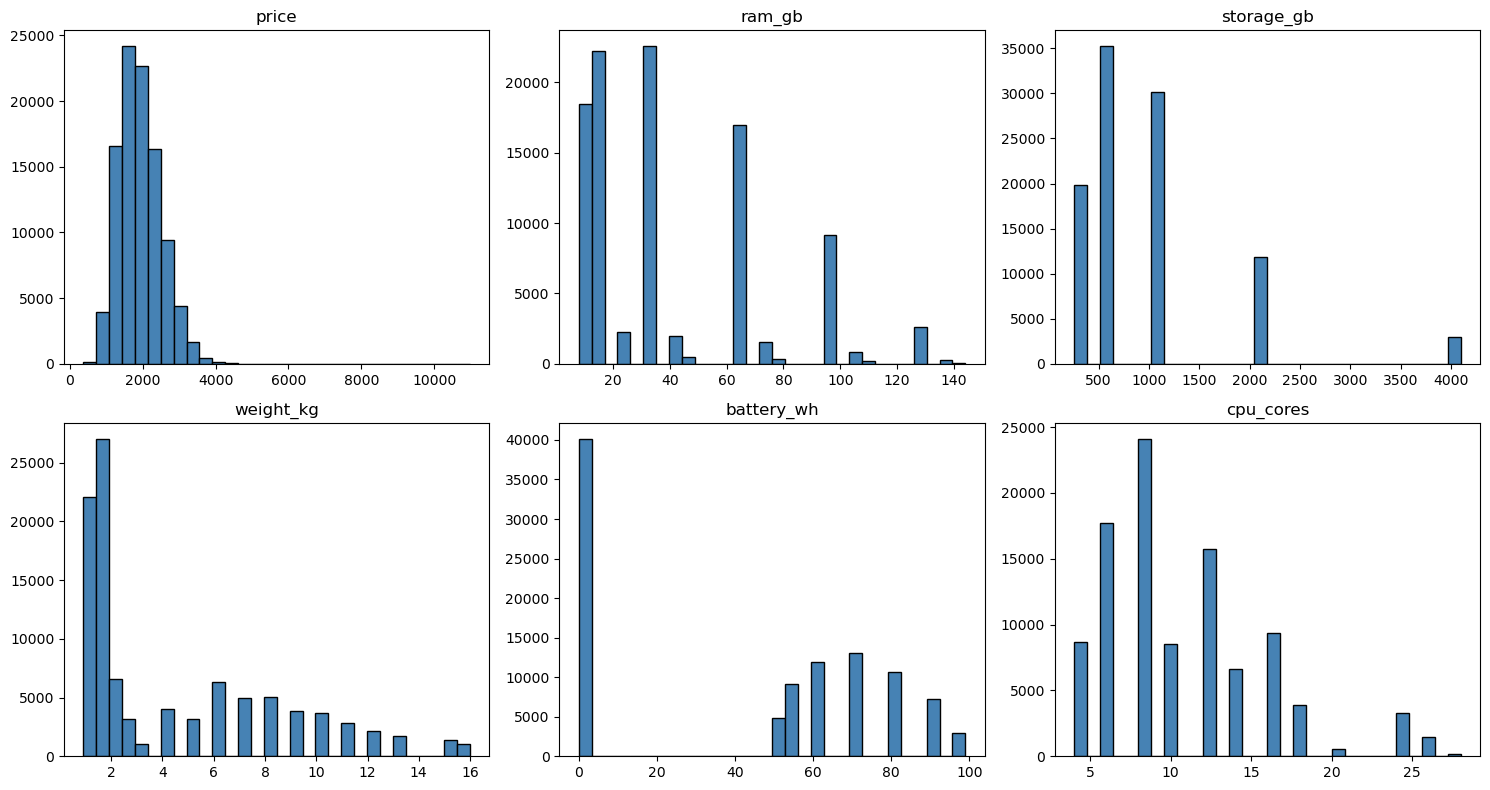

In [7]:
num_features = ['price', 'ram_gb', 'storage_gb', 'weight_kg', 'battery_wh', 'cpu_cores']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(col)
plt.tight_layout()

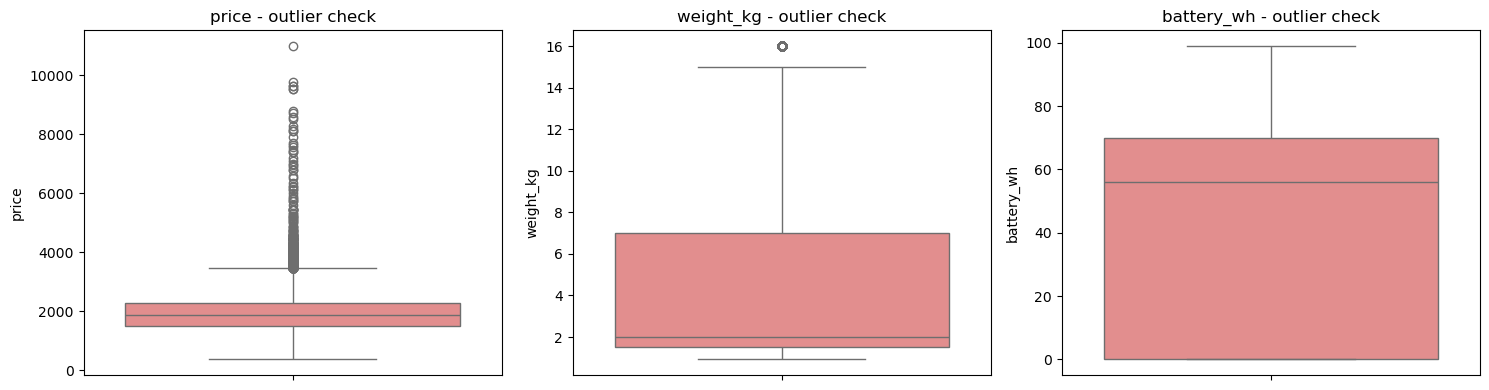

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['price', 'weight_kg', 'battery_wh']):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'{col} - outlier check')
plt.tight_layout()

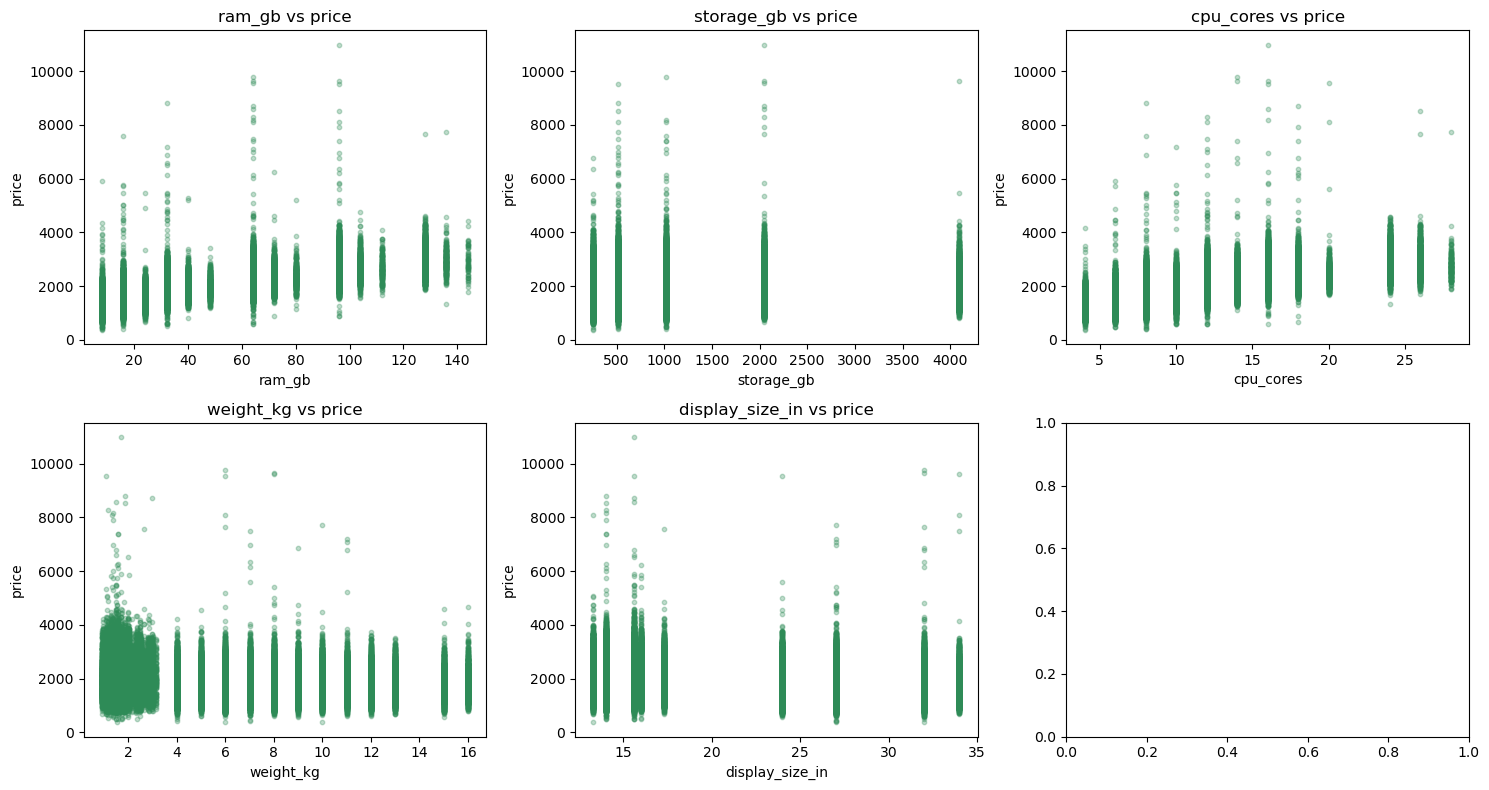

In [9]:
scatter_features = ['ram_gb', 'storage_gb', 'cpu_cores', 'weight_kg', 'display_size_in']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(scatter_features):
    axes[i].scatter(df[col], df['price'], alpha=0.3, s=10, color='seagreen')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('price')
    axes[i].set_title(f'{col} vs price')
plt.tight_layout()

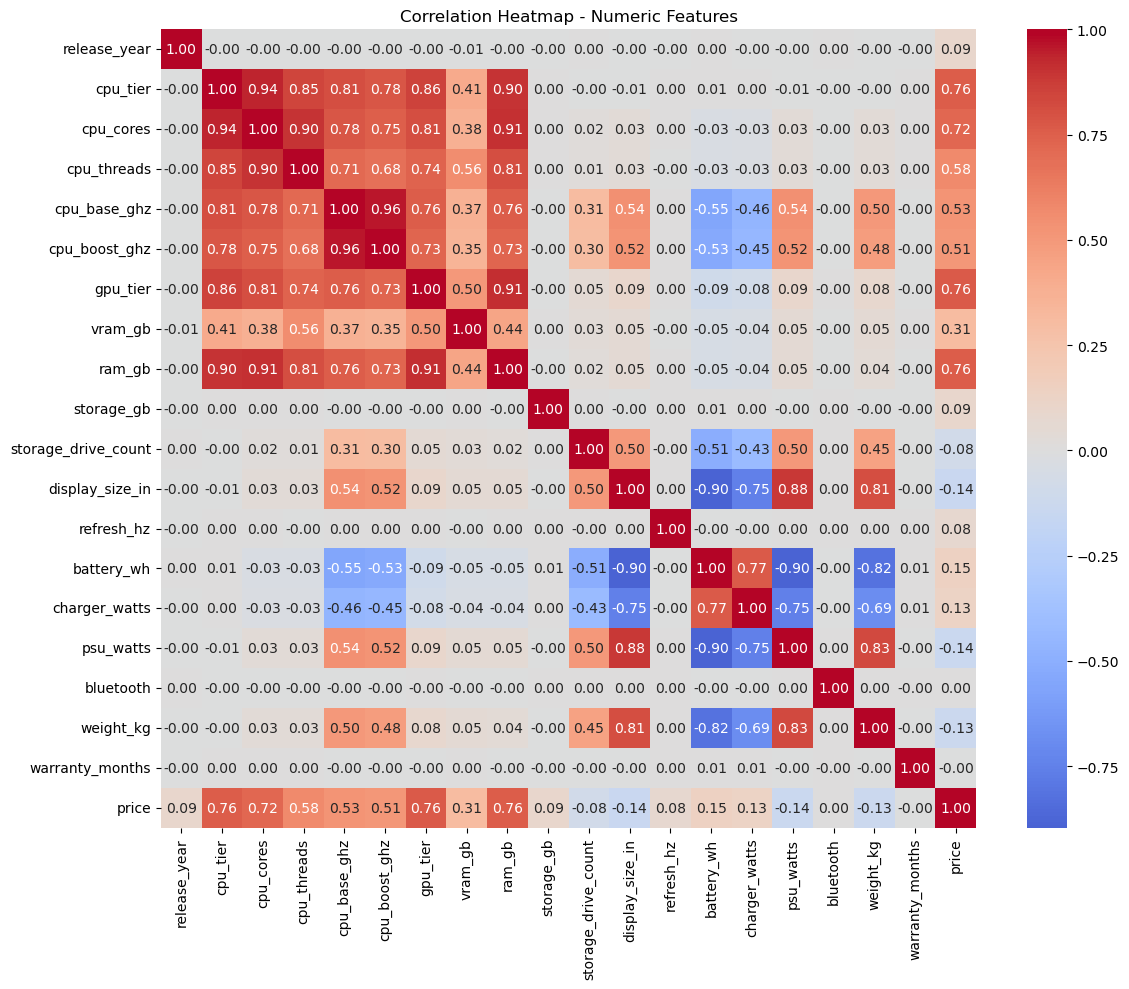

In [10]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 10))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Numeric Features')
plt.tight_layout()

Price skewness: 0.9866439454826046


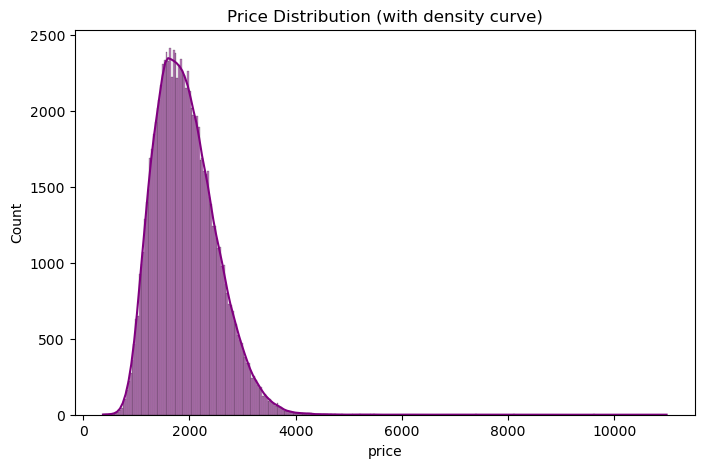

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], kde=True, color='purple')
plt.title('Price Distribution (with density curve)')
print("Price skewness:", df['price'].skew())

Conclusion 
* price is clearly right-skewed, peak around $1,600–2,000, with a long tail stretching to $10,000. A log1p(price) transform will help, especially for Linear/Ridge/Lasso/SVR.
* ram_gb and storage_gb, cpu_core have no smooth curves. they spike at standard size.
* weight_kg is heavily concetrated at the low end but a specific outlier availble at the right end  .
* battery_wh spikes at zero which implies our dataset mixes laptops and desktops.
* Skewness = 0.987 — moderate-to-strong right skew (a value above ~0.5 is generally considered notably skewed, above 1 is strong). This is our concrete justification to apply np.log1p(price) before training, particularly for the linear/distance-based models.   
   * many machine learning algorithms perform poorly when the target variable has a heavy right tail. it stabilizzes variance, Normalizes the Error    Distribution, Minimizes the Impact of Outliers.

### 6. Data Preprocessing 

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [13]:
# 1. Extract generation and suffix using vectorized regex
gen_pattern = r'(?:Arc\s+(?P<A>A)?(?P<B>B)?|(?:RTX|RX)\s+(?P<num>\d+))'
sfx_pattern = r'\b(?P<gpu_suffix>Ti|XT|Super|Limited)\b'

extracted_gen = df['gpu_model'].str.extract(gen_pattern)
df['gpu_suffix'] = df['gpu_model'].str.extract(sfx_pattern).fillna('None')

# 2. Convert Intel Arc letters to numbers, fallback to regex numbers, and fill missing/Apple with 0
df['gpu_generation'] = (
    extracted_gen['A'].notna() * 1 + 
    extracted_gen['B'].notna() * 2 + 
    extracted_gen['num'].fillna(0).astype(int)
)
df.loc[df['gpu_model'].str.contains('Apple', na=True), ['gpu_generation', 'gpu_suffix']] = [0, 'None']

# 3. Print counts and drop columns
print(df['gpu_generation'].value_counts())
print(df['gpu_suffix'].value_counts())
df = df.drop(columns=['gpu_model', 'cpu_model', 'model'], errors='ignore')

gpu_generation
40      24648
30      24551
0       18922
1        8502
7000     7078
6000     7074
20       5513
2        2097
5000     1615
Name: count, dtype: int64
gpu_suffix
None       91675
Ti          6008
XT          1827
Limited      490
Name: count, dtype: int64


In [14]:
# Parse "1920x1080" into total pixel count
res_split = df['resolution'].str.split('x', expand=True).astype(int)
df['resolution_pixels'] = res_split[0] * res_split[1]
df.drop('resolution', axis=1, inplace=True)

In [15]:
#log transform the target
df['price'] = np.log1p(df['price'])

In [16]:
X = df.drop('price', axis=1)
y = df['price']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
categorical_cols = ['device_type', 'brand', 'os', 'form_factor',
                     'cpu_brand', 'cpu_tier', 'gpu_brand', 'gpu_tier',
                     'storage_type', 'display_type', 'gpu_suffix',
                     'wifi', 'bluetooth']

numerical_cols = ['release_year', 'cpu_cores', 'cpu_threads',
                   'cpu_base_ghz', 'cpu_boost_ghz', 'vram_gb', 'ram_gb',
                   'storage_gb', 'storage_drive_count', 'display_size_in',
                   'refresh_hz', 'battery_wh', 'charger_watts',
                   'psu_watts', 'weight_kg', 'warranty_months',
                   'gpu_generation', 'resolution_pixels']

In [19]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categorical_cols)
])

# Fit on train ONLY, then transform both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

### 7. Regression Models, Evaluations, & Comparisions

In [20]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.utils import resample
from xgboost import XGBRegressor
import time

In [22]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=0.01, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

trained_models = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train_processed, y_train)
    trained_models[name] = model
    print(f"{name} trained in {time.time() - start:.1f} sec")

X_train_svr, y_train_svr = resample(X_train_processed, y_train, n_samples=8000, random_state=42)

start = time.time()
svr_model = SVR()
svr_model.fit(X_train_svr, y_train_svr)
trained_models['SVR'] = svr_model
print(f"SVR trained in {time.time() - start:.1f} sec")

Linear Regression trained in 0.8 sec
Ridge Regression trained in 0.1 sec
Lasso Regression trained in 1.7 sec
Decision Tree trained in 3.2 sec
Random Forest trained in 200.1 sec
Gradient Boosting trained in 65.9 sec
XGBoost trained in 1.0 sec
SVR trained in 2.4 sec


* alpha in Ridge/Lasso controls regularization strength
* This will take a little time for Random Forest/Gradient Boosting/XGBoost since they're ensembles — that's normal, just let it run.
* SVR was trained on a random subsample of 8,000 rows (rather than the full 99,999) due to its O(n²)-O(n³) computational complexity, which makes it impractical at full scale — a well-known scalability limitation of kernel-based SVMs. This is expected to put SVR at a disadvantage relative to models trained on the full dataset, and its results should be interpreted with that caveat in mind."

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

# convert true test values back to real price once
y_test_actual = np.expm1(y_test)

for name, model in trained_models.items():
    y_pred_log = model.predict(X_test_processed)
    y_pred_actual = np.expm1(y_pred_log)  # back to real dollars

    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    mse = mean_squared_error(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_actual, y_pred_actual)

    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
print(results_df)

               Model         MAE            MSE        RMSE        R2
0            XGBoost  141.131038   40980.482014  202.436365  0.875897
1   Ridge Regression  148.060098   44166.478736  210.158223  0.866249
2  Linear Regression  148.059822   44166.541289  210.158372  0.866249
3  Gradient Boosting  152.028924   45438.487508  213.163054  0.862397
4                SVR  153.272083   46814.061350  216.365573  0.858231
5      Random Forest  157.074687   48768.188587  220.835207  0.852313
6   Lasso Regression  205.610737   76775.310496  277.083580  0.767498
7      Decision Tree  231.030550  113671.150450  337.151524  0.655765


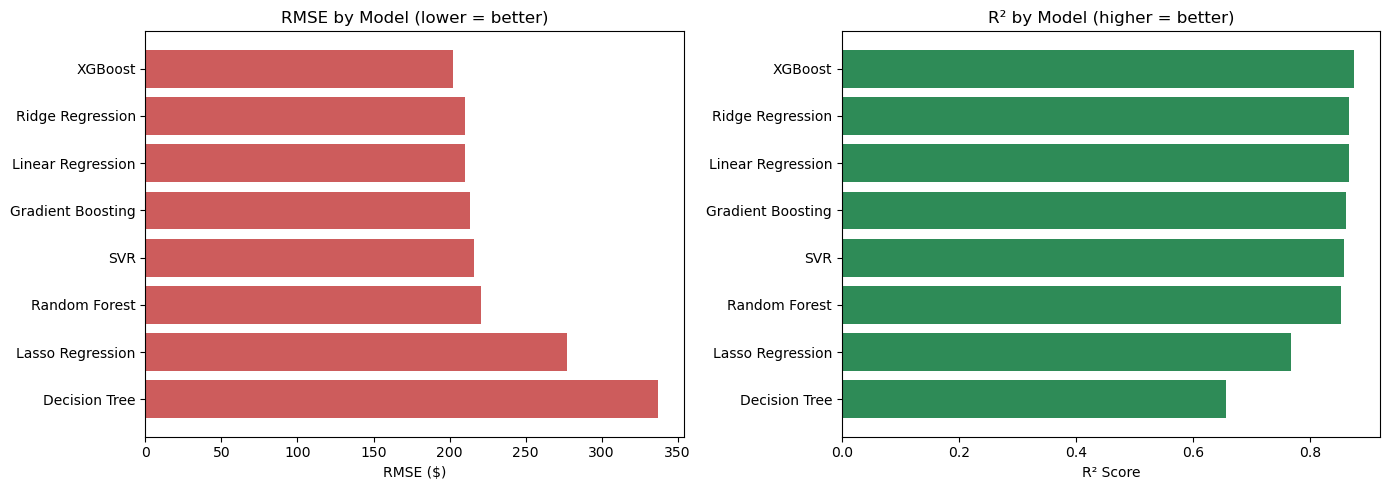

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(results_df['Model'], results_df['RMSE'], color='indianred')
axes[0].set_xlabel('RMSE ($)')
axes[0].set_title('RMSE by Model (lower = better)')
axes[0].invert_yaxis()

axes[1].barh(results_df['Model'], results_df['R2'], color='seagreen')
axes[1].set_xlabel('R² Score')
axes[1].set_title('R² by Model (higher = better)')
axes[1].invert_yaxis()

plt.tight_layout()

#### what each metric measures
* MAE: Average absolute difference between predicted and actual price. If MAE is 150 the model is off by 150 on average, in either direction.
* MSE: Same idea as MAE, but errors are squared before averaging. This punishes large errors much more heavily than small ones.
* RMSE: Square root of MSE — brings the units back to actual dollars, while still keeping the "big errors matter more" property from MSE.
* R2: What proportion of the variance in price your model explains. R²=1 means the model perfectly explains price using the features. R²=0 means it's no better than just predicting the average price every time. Can even go negative if the model is worse than that baseline.

#### Who won? 
* XGBoost
  * R2 = 0.876 means XGBoost explains about 87.6% of the variance in laptop prices using just the specs
  * MAE = 141 — on laptops averaging somewhere around 1,500-2,000 being off by ~141 on average is roughly a 7-9% error
#### why did it perform better?
* Feature interactions — price likely depends on combinations of specs (e.g. high RAM only commands a premium when paired with a high-end CPU/GPU too). XGBoost builds trees that can naturally split on one feature conditioned on another
* Boosting corrects errors iteratively — unlike Random Forest (which averages many independent trees), XGBoost trains trees sequentially, each one specifically targeting the previous tree's mistakes. This is likely why it beat Gradient Boosting too (similar idea, but XGBoost has more refined regularization and optimization) and clearly outperformed Random Forest.

### 8. Experimenting 

lets try to tune our 3 best performing models to make them even better using randomizedSearchCv and gridSearchCv

In [25]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=20,             # number of random combinations to try
    scoring='neg_mean_squared_error',
    cv=5,                
    verbose=2,
    random_state=42,
    n_jobs=-1               # use all CPU cores
)

xgb_search.fit(X_train_processed, y_train)

print("Best params:", xgb_search.best_params_)
best_xgb = xgb_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.8}


In [28]:
param_dist_gb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

gb_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist_gb,
    n_iter=10,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

gb_search.fit(X_train_processed, y_train)
print("Best params:", gb_search.best_params_)
best_gb = gb_search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1}


In [29]:
# we are using a full GridSearchCV here since it only has 1 real hyperparameter
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 5, 10, 50, 100]}

ridge_search = GridSearchCV(
    estimator=Ridge(random_state=42),
    param_grid=ridge_params,
    scoring='neg_mean_squared_error',
    cv=5
)

ridge_search.fit(X_train_processed, y_train)
print("Best alpha:", ridge_search.best_params_)
best_ridge = ridge_search.best_estimator_

Best alpha: {'alpha': 1}


In [32]:
param_dist_svr = {
    'C': [0.1, 1, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'epsilon': [0.01, 0.1, 0.2, 0.5]
}

svr_search = RandomizedSearchCV(
    estimator=SVR(),
    param_distributions=param_dist_svr,
    n_iter=20,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

svr_search.fit(X_train_svr, y_train_svr)   # the same 8,000-row subsample from before
print("Best SVR params:", svr_search.best_params_)
best_svr = svr_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best SVR params: {'gamma': 0.01, 'epsilon': 0.01, 'C': 1}


In [33]:
tuned_models = {
    'XGBoost (Tuned)': xgb_search.best_estimator_,
    'Gradient Boosting (Tuned)': gb_search.best_estimator_,
    'Ridge (Tuned)': ridge_search.best_estimator_,
    'SVR (Tuned)': svr_search.best_estimator_
}

tuned_results = []

for name, model in tuned_models.items():
    y_pred_log = model.predict(X_test_processed)
    y_pred_actual = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    mse = mean_squared_error(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_actual, y_pred_actual)

    tuned_results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

tuned_results_df = pd.DataFrame(tuned_results).sort_values('R2', ascending=False).reset_index(drop=True)
print(tuned_results_df)

                       Model         MAE           MSE        RMSE        R2
0            XGBoost (Tuned)  137.583199  38867.529025  197.148495  0.882296
1  Gradient Boosting (Tuned)  137.973205  39208.623430  198.011675  0.881263
2                SVR (Tuned)  144.927404  42402.682522  205.919116  0.871590
3              Ridge (Tuned)  148.060098  44166.478736  210.158223  0.866249


In [34]:
results_df['Version'] = 'Baseline'
tuned_results_df['Version'] = 'Tuned'

comparison_df = pd.concat([results_df, tuned_results_df], ignore_index=True)
comparison_df = comparison_df.sort_values('R2', ascending=False).reset_index(drop=True)
print(comparison_df)

                        Model         MAE            MSE        RMSE  \
0             XGBoost (Tuned)  137.583199   38867.529025  197.148495   
1   Gradient Boosting (Tuned)  137.973205   39208.623430  198.011675   
2                     XGBoost  141.131038   40980.482014  202.436365   
3                 SVR (Tuned)  144.927404   42402.682522  205.919116   
4            Ridge Regression  148.060098   44166.478736  210.158223   
5               Ridge (Tuned)  148.060098   44166.478736  210.158223   
6           Linear Regression  148.059822   44166.541289  210.158372   
7           Gradient Boosting  152.028924   45438.487508  213.163054   
8                         SVR  153.272083   46814.061350  216.365573   
9               Random Forest  157.074687   48768.188587  220.835207   
10           Lasso Regression  205.610737   76775.310496  277.083580   
11              Decision Tree  231.030550  113671.150450  337.151524   

          R2   Version  
0   0.882296     Tuned  
1   0.881263 

Final winner: XGBoost (Tuned)
MAE = $137.58, RMSE = $197.15, R² = 0.8823 — the best model overall, across every metric.

### 9. Model Selection and Saving 

we need to save the preprocessor (ColumnTransformer) too. Any new laptop data you want to predict on later will come in as raw specs (brand="Dell", ram_gb=16, etc.), and it needs to go through the exact same scaling/encoding transformation before it can be fed to the model. If you only save the model and rebuild the preprocessor from scratch later, you risk subtle mismatches (different column order, different one-hot categories, etc.) that silently break predictions.

In [36]:
import joblib

# Save the final tuned XGBoost model
joblib.dump(xgb_search.best_estimator_, 'laptop_price_model.pkl')

# Save the preprocessor (scaler + encoder) used to transform features
joblib.dump(preprocessor, 'laptop_price_preprocessor.pkl')

print("Model and preprocessor saved.")

Model and preprocessor saved.


In [37]:
loaded_model = joblib.load('laptop_price_model.pkl')
loaded_preprocessor = joblib.load('laptop_price_preprocessor.pkl')

# quick check: does it reproduce the same predictions?
check_pred = loaded_model.predict(X_test_processed[:5])
print(check_pred)

[7.540698  7.3479896 7.5973735 7.810902  7.2820783]


In [41]:
comparison_df.to_csv('comparison_results.csv', index=False)